# Does the Economy Change the Music Which We Listen To?
### An Analysis Into 50 Years of Billboard Top 100 Songs Against US Macroeconomic Data (1975-2025)

Music is often seen as a mirror of society. When times are good it is assumed that we listen to upbeat and danceable music. When times are harder, recessions and periods of higher unemployment, we indulge in darker and slower music. But is there actually any evidence for this? 

The term 'Recession Pop' was coined back in 2008, but the concept of the popularisation of disco and house music during economic downturn long predated this. In 2020 the BBC found that 'The average tempo of 2020’s top 20 best-selling songs is a pulse-quickening 122 beats per minute. That’s the highest it’s been since 2009.' This clashes with what many people may initially assume how macroeconomic factors affect the tempo of music. 

In this blog we take 50 years of the Billboard Top 100 year-end charts and compare them against US macroeconomic data. We aim to test whether the tempo and mood of America's most popular songs systematically shifts with the prosperity of the economy. There will be a particular focus on two major economic shocks: the 2008 Global Financial Crisis and the COVID-19 pandemic of 2020. 

The two musical variables include:
- **BPM (beats per minute):** How fast a song is, a higher BPM infers a song is more energetic
- **Valence:** A score from 0 to 1 measuring musical 'positiveness', a score of 1 indicates the song is happy and euphoric while 0 indicates it might be sad or tense. 

The two Macroeconomic varables include:
- **Unemployment rate:** The percentage of US labour force without a job
- **GDP growth rate:** How much the US economy changed that year (positively or negatively) 

In [4]:
#setting up, importing libraries and relevant datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('~/Dekstop', exist_ok=True)

#setting up a clean and consistent visual style for all plots 
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

#colours
BLUE = '#70BDFF'
ORANGE = '#FFA34F'
GREEN = '#71D46C'
PURPLE = '#D384E3'
RED_FILL = '#FFEBEE'

#loading merged annual dataset
github_url = 'https://raw.githubusercontent.com/Liviah27/Empirical-Project-Data-Science-26/refs/heads/processed/annual_merged.csv'
df = pd.read_csv(github_url)
print(f'Dataset loaded: {len(df)} years ({df["year"].min()}-{df["year"].max()})')


Dataset loaded: 51 years (1975-2025)


## How Have BPM and Valence Changed Over 50 Years?
Before testing it against macroeconomic data, it is worth simply looking at how mood and tempo of popular music has changed across the last 5 decades. 

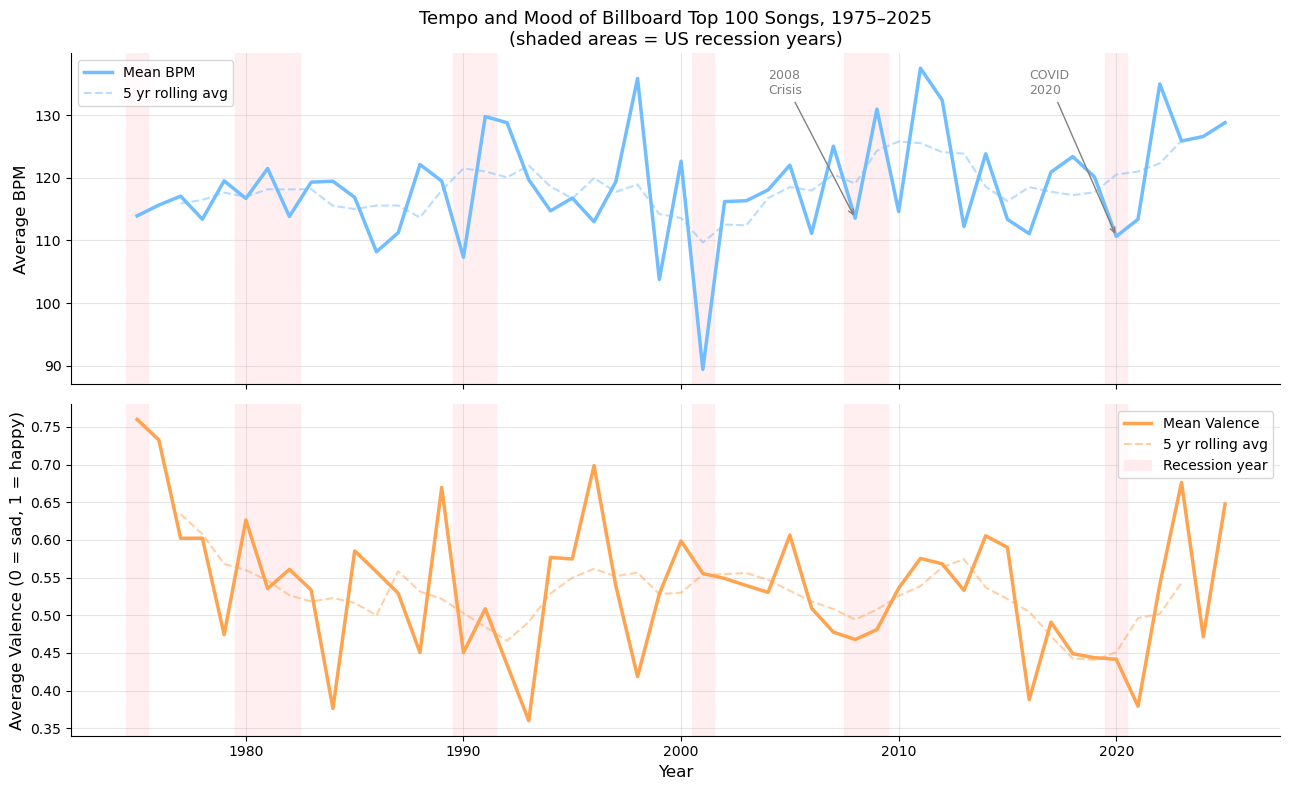

Figure 1 saved


In [19]:
#figure 1, avg bpm and valence over time 
#dual time series plot demonstrating both variables side by side with recession years shaded

recession_years = df[df['recession'] == 1]['year'].tolist()

#grouping consecutive recessions years into spans
def get_recession_spans(years):
    spans, start = [], None
    for i, y in enumerate(sorted(years)):
        if start is None:
            start = y
        if i == len(years)-1 or years[i+1] - y > 1:
            spans.append((start, y))
            start = None
    return spans

recession_spans = get_recession_spans(sorted(recession_years))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (13, 8), sharex= True)

for ax in [ax1, ax2]:
    for start, end in recession_spans:
        ax.axvspan(start-0.5, end + 0.5, color=RED_FILL, alpha=0.8, zorder=0)

#BPM

ax1.plot(df['year'], df['mean_bpm'], color = BLUE, linewidth=2.5, label='Mean BPM')
ax1.plot(df['year'], df['mean_bpm'].rolling(5, center=True).mean(),
        color=BLUE, linewidth=1.5, linestyle='--', alpha=0.5, label='5 yr rolling avg')
ax1.set_ylabel('Average BPM', fontsize=12)
ax1.set_title('Tempo and Mood of Billboard Top 100 Songs, 1975–2025\n'
              '(shaded areas = US recession years)', fontsize=13)
ax1.legend(fontsize=10)
ax1.annotate('2008\nCrisis', xy=(2008, df.loc[df['year']==2008, 'mean_bpm'].values[0]),
             xytext=(2004, df['mean_bpm'].max() *0.97),
             arrowprops=dict(arrowstyle='->', color='grey'),
             fontsize=9, color='grey')
ax1.annotate('COVID\n2020', xy=(2020, df.loc[df['year']==2020, 'mean_bpm'].values[0]),
             xytext=(2016, df['mean_bpm'].max()* 0.97),
             arrowprops=dict(arrowstyle='->', color='grey'),
             fontsize=9, color='grey')

#valence
ax2.plot(df['year'], df['mean_valence'], color=ORANGE, linewidth=2.5, label='Mean Valence')
ax2.plot(df['year'], df['mean_valence'].rolling(5, center=True).mean(),
         color=ORANGE, linewidth=1.5, linestyle='--', alpha=0.5, label='5 yr rolling avg')
ax2.set_ylabel('Average Valence (0 = sad, 1 = happy)', fontsize=12)
ax2.set_xlabel('Year', fontsize=12)
ax2.legend(fontsize=10)

recession_patch = mpatches.Patch(color=RED_FILL, label = 'Recession year')
ax2.legend(handles=[ax2.lines[0], ax2.lines[1], recession_patch], fontsize=10)

plt.tight_layout()
plt.savefig('~/Desktop/fig1_bpm_valence_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved')


The figure above (Figure 1) reveals that there seems to be a relationship between Average BPM and years in which the USA experienced recessions. There are significant peaks and troughs that can be observed. While for BPM these extremeties are located around years in which the USA underwent a negative change in real GDP, for valence there does not seem to be such a clear correlation between the two. 

Interestingly, the average BPM of American music during these recessions does not follow a consistent negative or positive correlation. In 2002 a deep trough in average BPM (the lowest recorded) can be observed, however, around 1990 we see a dip and then a peak in average BPM. These immediate observations could indicate that economic downturns could encourage opposing musical responses; consumers may turn to slower and sadder music in emotional refelection or energetic and upbeat music in escapism.   

## A Closer Look Into The 2008 Crisis and COVID 19
The figures below demonstrate the average BPM and Valence surrounding both significant economic downturns. There is no noteable change in either that can be observed in these columns besides a slight dip around around years of recession. However, we can observe a significantly lower average valence around COVID 19 when compared to the 2008 crisis. This is likely a result of change in preference of musical genres rather than a direct effect of either recessions. 


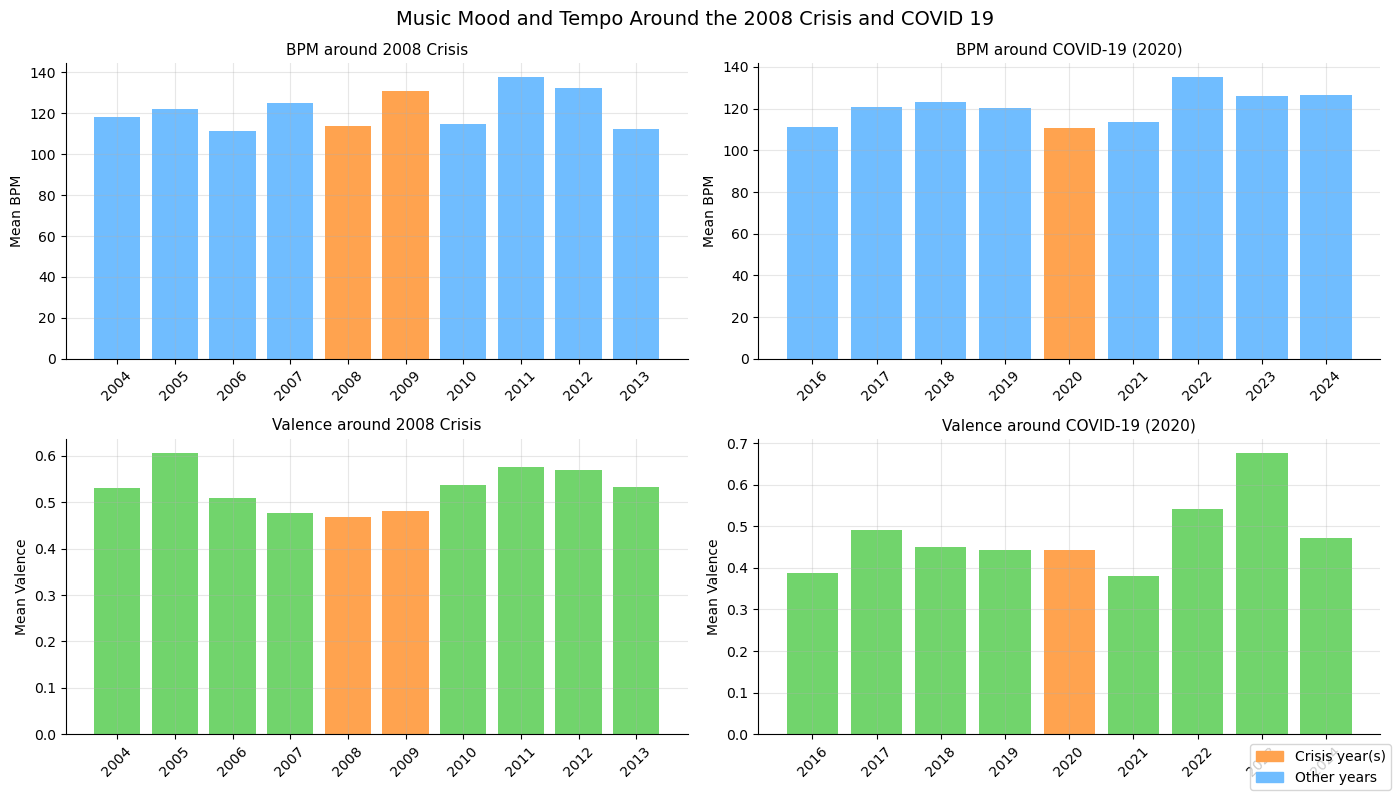

figure 2 saved


In [21]:
#figure 2, focusing on 2005-2013 and 2017-2023, side by side panels demonstrating musical and economic change over these crisis'

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Music Mood and Tempo Around the 2008 Crisis and COVID 19', fontsize=14)

#2008
window_2008 = df[(df['year'] >=2004) & (df['year'] <=2013)]

#BPM around 2008
ax = axes [0, 0]
ax.bar(window_2008['year'], window_2008['mean_bpm'],
       color=[ORANGE if y in [2008, 2009] else BLUE for y in window_2008['year']])
ax.set_title('BPM around 2008 Crisis', fontsize=11)
ax.set_ylabel('Mean BPM')
ax.set_xticks(window_2008['year'])
ax.tick_params(axis='x', rotation=45)


#valence around 2008 
ax = axes [1, 0]
ax.bar(window_2008['year'], window_2008['mean_valence'],
       color=[ORANGE if y in [2008, 2009] else GREEN for y in window_2008['year']])
ax.set_title('Valence around 2008 Crisis', fontsize=11)
ax.set_ylabel('Mean Valence')
ax.set_xticks(window_2008['year'])
ax.tick_params(axis='x', rotation=45)

#covid 
window_covid = df[(df['year'] >=2016) & (df['year'] <= 2024)]

#BPM around covid
ax = axes [0, 1]
ax.bar(window_covid['year'], window_covid['mean_bpm'],
       color=[ORANGE if y == 2020 else BLUE for y in window_covid['year']])
ax.set_title('BPM around COVID-19 (2020)', fontsize=11)
ax.set_ylabel('Mean BPM')
ax.set_xticks(window_covid['year'])
ax.tick_params(axis='x', rotation=45)

#valence 
ax = axes [1, 1]
ax.bar(window_covid['year'], window_covid['mean_valence'],
       color=[ORANGE if y == 2020 else GREEN for y in window_covid['year']])
ax.set_title('Valence around COVID-19 (2020)', fontsize=11)
ax.set_ylabel('Mean Valence')
ax.set_xticks(window_covid['year'])
ax.tick_params(axis='x', rotation=45)

crisis_patch = mpatches.Patch(color=ORANGE, label='Crisis year(s)')
normal_patch = mpatches.Patch(color=BLUE, label='Other years')
fig.legend(handles=[crisis_patch, normal_patch], loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('~/Desktop/fig2_crisis_zoom.png', dpi=150, bbox_inches='tight')
plt.show()
print('figure 2 saved')


## Visuallising the Correlation Between Macroeconomic Factors and Musical Variables 

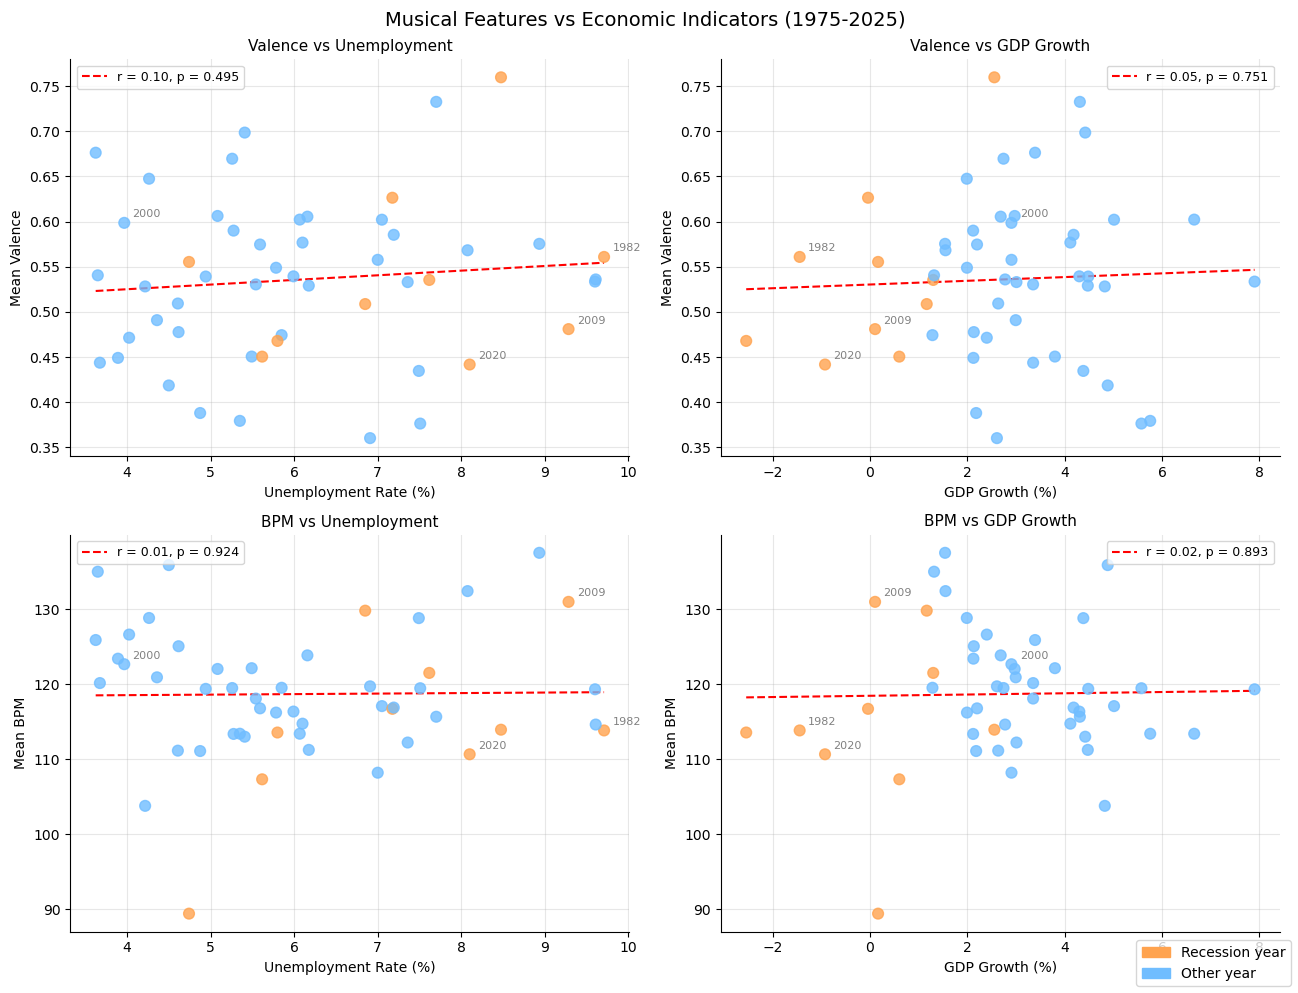

figure 3 saved
  mean_valence vs unemployment_rate: r = 0.098, p = 0.495
  mean_valence vs gdp_growth_pct: r = 0.046, p = 0.751
  mean_bpm vs unemployment_rate: r = 0.014, p = 0.924
  mean_bpm vs gdp_growth_pct: r = 0.019, p = 0.893


In [23]:
#figure 3, scatter plots BPM and Valence vs unemp and GDP growth 
#recession dots in orange to show if in particular region

df_clean = df.dropna(subset=['mean_bpm', 'mean_valence', 'unemployment_rate', 'gdp_growth_pct'])

pairs = [
    ('unemployment_rate', 'mean_valence', 'Unemployment Rate (%)', 'Mean Valence', 'Valence vs Unemployment'),
    ('gdp_growth_pct', 'mean_valence', 'GDP Growth (%)', 'Mean Valence', 'Valence vs GDP Growth'),
    ('unemployment_rate', 'mean_bpm', 'Unemployment Rate (%)', 'Mean BPM', 'BPM vs Unemployment'),
    ('gdp_growth_pct', 'mean_bpm', 'GDP Growth (%)', 'Mean BPM', 'BPM vs GDP Growth'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Musical Features vs Economic Indicators (1975-2025)', fontsize=14)

for ax, (x_col, y_col, x_label, y_label, title) in zip(axes.flat, pairs):
    colors = [ORANGE if r == 1 else BLUE for r in df_clean['recession']]
    ax.scatter(df_clean[x_col], df_clean[y_col], c=colors, s=60, alpha=0.8, zorder=3)
    
    #annotating a few interesting years
    for _, row in df_clean[df_clean['year'].isin([2009, 2020, 1982, 2000])].iterrows():
        ax.annotate(str(int(row['year'])),
                    (row[x_col], row[y_col]),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=8, color='grey')
    
    #adding an OLS trend line
    m, b, r, p, _ = stats.linregress(df_clean[x_col], df_clean[y_col])
    x_range = np.linspace(df_clean[x_col].min(), df_clean[x_col].max(), 100)
    ax.plot(x_range, m * x_range + b, color='red', linewidth=1.5,
            linestyle='--', label=f'r = {r:.2f}, p = {p:.3f}')
    
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)

recession_patch = mpatches.Patch(color=ORANGE, label='Recession year')
normal_patch = mpatches.Patch(color=BLUE, label='Other year')
fig.legend(handles=[recession_patch, normal_patch], loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('~/Desktop/fig3_scatter_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('figure 3 saved')
for x_col, y_col, *_ in pairs:
    r, p = stats.pearsonr(df_clean[x_col].dropna(), df_clean[y_col].dropna())
    print(f'  {y_col} vs {x_col}: r = {r:.3f}, p = {p:.3f}')



Immediately, there does not seem to be much of a correlation between any of these variables all demonstrating a strikingly low r-value and high p-value. These indicate that this relationship is not statictially significant from the values we have obtained (as they do not come close to the conventional p < 0.05). This could be a result of many issues such as a small sample size (as we only had a 10% bpm match rate) and the average bpm and valence of music being influenced by various other more significant factors such as change in popular genres or politics. Furthermore, it was observed that there were extreme peaks and troughs in average BPM during recessionns which, in this case, would offset each other significantly and greatly decrease correlation between GDP Growth and BPM.


Noteably, there are a multitude of reports that can be accessed that discuss a very similar topic to this blog which have discovered there to be a negative correlation between tempo and Valence against GDP growth. In 2012 the  director of consumer trends at Mintel, Alexandra Smith, noted that bands like Skrillex, Lady Gaga and Robyn are "put-your-headphones-on, tune-the-world-out music, (...) it tends to be really upbeat.  And it really makes sense, when times are tough, you’re going to want to turn to that type of music”. This indicates that there should be a negative relationship between real GDP Growth and BPM that can be found within this data.

## Regression Analysis 

As scatter plots provide a visual sense of correlation, regression quantifies the relationship while conrtolling other variables. BPM has demonstrated an upward trend over the decades which we need to seperate the effect of the economy on this underlying time trend.  

We estimate four OLS models, the year variable controls for any long-run time trend in music so we can isolate the independant effect of macroeconomic conditions. 

In [25]:
#regression models, ols fegression using statsmodels
#estimating models: 1: valence - unemployment+gdp groeth+time trend
#2: bpm- unemployment+gdp groeth+time trend
#Valence- model 1 +recession dummy (does being in recession add extar effect)
#valence- lagged unemployment(does last years economy predict this years music?)

df_reg = df.dropna(subset=['mean_valence', 'mean_bpm', 'unemployment_rate',
                            'gdp_growth_pct', 'recession', 'unemployment_lag1'])

# model 1: valence ~ economic conditions
model1 = smf.ols(
    'mean_valence ~ unemployment_rate + gdp_growth_pct + year',
    data=df_reg
).fit()

#model 2: bpm ~ economic conditions
model2 = smf.ols(
    'mean_bpm ~ unemployment_rate + gdp_growth_pct + year',
    data=df_reg
).fit()

#model 3: valence ~ economic conditions + recession dummy
model3 = smf.ols(
    'mean_valence ~ unemployment_rate + gdp_growth_pct + recession + year',
    data=df_reg
).fit()

#model 4: valence ~ lagged unemployment 
model4 = smf.ols(
    'mean_valence ~ unemployment_lag1 + gdp_growth_lag1 + year',
    data=df_reg
).fit()

print('All models estimated successfully.')

All models estimated successfully.


In [27]:
#printing regression results 

print('=' * 60)
print('Model 1: Valence ~ Unemployment + GDP Growth + Year')
print('=' * 60)
print(model1.summary().tables[1]) 
print(f'R-squared: {model1.rsquared:.3f}')

print('\n' + '=' * 60)
print('Model 2: BPM ~ Unemployment + GDP Growth + Year')
print('=' * 60)
print(model2.summary().tables[1])
print(f'R-squared: {model2.rsquared:.3f}')

print('\n' + '=' * 60)
print('Model 3: Valence ~ Unemployment + GDP Growth + Recession + Year')
print('=' * 60)
print(model3.summary().tables[1])
print(f'R-squared: {model3.rsquared:.3f}')

print('\n' + '=' * 60)
print('Model 4: Valence ~ Lagged Unemployment + Lagged GDP Growth + Year')
print('=' * 60)
print(model4.summary().tables[1])
print(f'R-squared: {model4.rsquared:.3f}')

Model 1: Valence ~ Unemployment + GDP Growth + Year
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             2.8690      1.954      1.469      0.149      -1.063       6.801
unemployment_rate    -0.0027      0.008     -0.332      0.742      -0.019       0.014
gdp_growth_pct        0.0001      0.006      0.017      0.987      -0.013       0.013
year                 -0.0012      0.001     -1.206      0.234      -0.003       0.001
R-squared: 0.035

Model 2: BPM ~ Unemployment + GDP Growth + Year
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          -284.0980    195.790     -1.451      0.154    -678.202     110.006
unemployment_rate     0.9151      0.818      1.118      0.269      -0.732       2.562
gdp_growth_pct        

In controlling the effect of time trends in music, the p-value for macroeconomic factors on the average BPM of music fell significantly. While for Valence, even with lagged variables and the inclusion of the binary recession variable, the p-value increased in comparison with the scatter plots. This has provided us with a more accurate representation of the relationship between musical varaibles and macroeconomic factors and confirms that there is no statistical significance between Tempo and Valence against GDP Growth and Unemployment Rate.  

There is a noteable exception to this, year is a significant predictor of BPM in the second model as p = 0.046 confirming the long-run upward trend in tempo observed visually. Inidicating that popular music in America has become faster over time, independent of economic conditions.

## Coefficient Plot 
To visualise the regression results, a coefficient plot will be used. The horizontal lines are 95% confidence intervals, if they cross zero the effect is not statistically significant. 

In figure 4 (the graphs below) it is observed, again, that both relationships are not statistically significant.

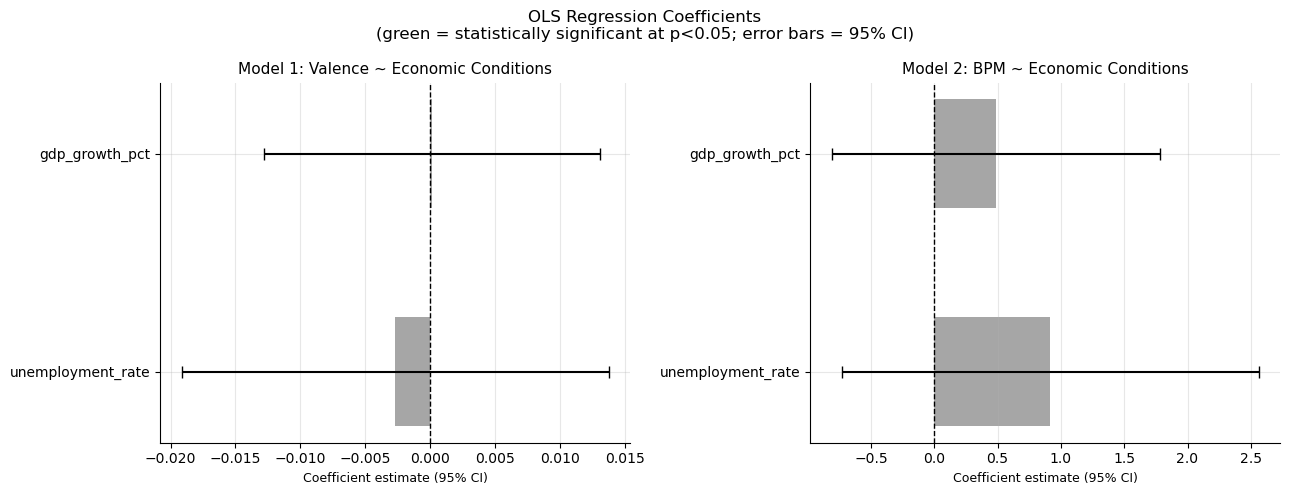

figure 4 saved


In [29]:
#figure 4, coefficient plot to visualise regression results

def plot_coefs(model, title, ax, exclude=['Intercept', 'year']):
    coefs = model.params.drop(labels=exclude, errors='ignore')
    errs = model.conf_int().drop(labels=exclude, errors='ignore')
    
    y_pos = range(len(coefs))
    colors = [GREEN if model.pvalues[name] < 0.05 else 'grey' for name in coefs.index]
    
    ax.barh(y_pos, coefs.values, xerr=[
        coefs.values - errs[0].values,
        errs[1].values - coefs.values
    ], color=colors, alpha=0.7, height=0.5, capsize=4)
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(coefs.index)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Coefficient estimate (95% CI)', fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('OLS Regression Coefficients\n'
             '(green = statistically significant at p<0.05; error bars = 95% CI)', fontsize=12)

plot_coefs(model1, 'Model 1: Valence ~ Economic Conditions', axes[0])
plot_coefs(model2, 'Model 2: BPM ~ Economic Conditions', axes[1])

plt.tight_layout()
plt.savefig('~/Desktop/fig4_regression_coefs.png', dpi=150, bbox_inches='tight')
plt.show()
print('figure 4 saved')

This statistical insignificance could be the result of multiple different factors, as mentioned before, there are a multitude of variables that influence the music to which we listen. It is therefore very difficult to mainly credit GDP Growth or Unemployment to the mood or tempo of music in the USA.

## Summary Statistics 
Comparing recession vs non recession years

In [31]:
#figure 5, summary statistics table, comparing recession vs mon recesion years

summary = df.groupby('recession').agg(
    mean_bpm = ('mean_bpm', 'mean'),
    mean_valence = ('mean_valence', 'mean'),
    mean_unemployed = ('unemployment_rate', 'mean'),
    mean_gdp_growth = ('gdp_growth_pct', 'mean'),
    n_years = ('year', 'count')
).round(3)

summary.index = ['Non-recession years', 'Recession years']
print('Summary Statistics: Recession vs Non-Recession Years')
print(summary.to_string())

# t-tests, are the differences in BPM and valence statistically significant?
recession_data = df[df['recession'] == 1]
non_recession_data = df[df['recession'] == 0]

for var, label in [('mean_valence', 'Valence'), ('mean_bpm', 'BPM')]:
    t, p = stats.ttest_ind(
        recession_data[var].dropna(),
        non_recession_data[var].dropna()
    )
    print(f'\nT-test for {label}: t = {t:.3f}, p = {p:.3f}',
          'SIGNIFICANT' if p < 0.05 else '(not significant)')

Summary Statistics: Recession vs Non-Recession Years
                     mean_bpm  mean_valence  mean_unemployed  mean_gdp_growth  n_years
Non-recession years   119.643         0.535            5.824            3.421       41
Recession years       114.771         0.539            7.337            0.095       10

T-test for Valence: t = 0.107, p = 0.915 (not significant)

T-test for BPM: t = -1.632, p = 0.109 (not significant)


Figure 5 demonstrates that there is a slight difference in mean BPM between recession and non-recession years, however, this is overshadowed by all the previous data which points towards there not being a statistically significant relationship between these variables. 


## Conclusion
So no, there is no significant evidence to suggest that the economy influences the music that we listen to. Although our analysis found that there is no statistically significant relationship between the macroeconomic variables studied and music (mood/ tempo), this result itself is revealing. It could suggest that popular music is shaped more by cultural dynamics, global influences or industry practices rather than domestic macroeconomic indicators. While some sources have claimed there to be a negative correlation between GDP and tempo, our findings highlight the importance of rigorously testing such claims. This null result reminds us that not every intuitive narrative holds up under scrutiny. Future research into this could increase the dataset, include alternative economic or social variables, or explore more complex models to better understand the relationship between music and society.


## Sources 
- **Billboard Year-End Hot 100** (1975-2025): scraped from wikipedia.com
- **BPM and Valence Data**: Scraped from Kaggle.com
- **GDP growth and unemployment rate**: US Federal Resereve FRED API (series GDPC1 and UNRATE)
- **Quotes**: (BBC, 2020) and (Vanek Smith, 2012)